<a href="https://colab.research.google.com/github/EkaterinaLime666/-/blob/main/%D0%A0%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D0%B1%D1%8A%D0%B5%D0%BA%D1%82%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pylab inline

#  Решение задачи классификации объектов.

Рассмотрим задачу классификации объектов по их признакам.

Задача классификации - одна из задач машинного обучения, имея признаковое описание объекта нужно определить, представителем какой группы он является.

## Постановка задачи. Загрузка данных и первичная обработка.

Предсказать ценовую категорию мобильного телефона по его характеристикам.

Подробное описание характеристик приводится на странице [Задача и данные ](https://www.kaggle.com/iabhishekofficial/mobile-price-classification), но их смысл понятен из обозначений.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

%matplotlib inline

In [ ]:
data = pd.read_csv("train.csv")

Посмотрим на первые 5 строк

In [ ]:
data.head()

Для удобства просмотра давайте транспонируем

In [ ]:
data.head().T

В столбце **price_range**  указана ценовая категория телефона.

Посмотрим, какие значения принимает этот признак.

Для этого выведем все уникальные значения.

In [ ]:
data.price_range.unique()

## Бинаризация целевого признака

**Бинаризация** — преобразование многоклассовой или непрерывной целевой переменной в бинарную (0/1). В контексте генетических алгоритмов это упрощает задачу оптимизации: вместо поиска множества классов или значений алгоритм фокусируется на разделении объектов на две группы.

Целевой признак (y) после бинаризации принимает значения:

0 — объект не принадлежит целевому классу;

1 — объект принадлежит целевому классу.



---



Сейчас в данных четыре класса, мы же упростим и будем предсказывать принадлежность телефона к классу 1 ("подороже")

Образуем новый столбец с бинарным (принимает значения 0 и 1) признаком: модель подешевле класс 0, модель подороже класс 1. Правило отнесения смотрите в коде.

In [ ]:
data['price_range_bin'] = [1 if x > 1 else 0 for x in data.price_range]

In [ ]:
data['price_range_bin']

Посмотрим опять на первые 5 телефонов. Обратите внимание на то, что новый столбец добавлен.

In [ ]:
data.head().T

In [ ]:
# полезная команда получить название столбцов!!
data.columns

Выделим из наших данных матрицу признаков Х и целевой признак у.

В матрицу признаков не должны попасть данные о ценовой категории!!!

In [ ]:
y = data.price_range_bin.values
X = data[data.columns[:-2]].values
X.shape, y.shape

## Разделение данных на обучающую и тестовую выборки

Для того, чтобы понять, как хорошо мы обучаем предсказательную модель, нам нужна размеченная выборка, на которой мы будем проверять.


Выборка, на которой мы учимся, не подходит для этих целей, так как знания об этих объектах уже будут лежать в нашей модели, а в реальной жизни будут встречаться и новые, ранее неизвестные объекты.

ВОПРОС: откуда нам взять размеченную выборку?
ОТВЕТ: давайте разделим наш датасет на две части, train и test.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=2018)

print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)

## Нормализация данных

Подгрузим пакет нормализации и функцию StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

Посмотрим на исходные значения характеристик

In [ ]:
X_train

Нормализуем данные, обучив StandardScaler на X_train, т.к. тестовые данные модель видеть не должна

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Посмотрим на нормализованные значения характеристик

In [ ]:
X_train

#Построение классификатора

## МЕТОД 1. Метод ближайших соседей. Метрики.

Самый простой способ предсказать класс объекта - это найти самый близкий к нему и приписать его к этому же классу.

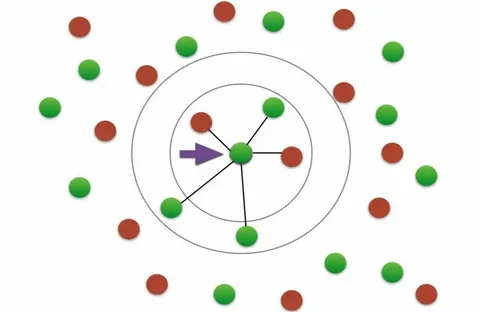

ВОПРОС: как определить схожесть между объектами в векторном представлении?

ОТВЕТ: Например, использовать косинусное расстояние:

$\text{cosine_similarity} = \cos(\theta) = {a \cdot b \over \|a\| \|b\|} = \frac{ \sum\limits_{i=1}^{n}{a_i \times b_i} }{ \sqrt{\sum\limits_{i=1}^{n}{(a_i)^2}} \times \sqrt{\sum\limits_{i=1}^{n}{(b_i)^2}} }$



Предсказывая принадлежность телефона к сегменту дорогих, мы можем совершить ошибки двух типов
* Ошибка первого рода (_type I errors, $\alpha$ errors, false positives_): ложное срабатывание предсказательной модели, в нашем случае телефон отнесен к числу дорогих, будучи дешевым
* Ошибка второго рода (_type II errors, $\beta$ errors, false negatives_): модель не выявила дорогой телефон, отнеся его к дешевым

ВОПРОС. Как оценить качество классификации?

ОТВЕТ. Использовать метрики.

### Метрики качества классификации

Метрик на самом деле придумать можно очень много. Остановимся на основных

![](http://blog.exsilio.com/wp-content/uploads/2016/09/table-blog.png)

**Точность (precision)**: $P = \frac{TP}{TP + FP}$

**Полнота (recall)**: $R = \frac{TP}{TP + FN}$

Точность показывает, какая доля объектов, выделенных классификатором как положительные, действительно является положительными.

Полнота показывает, какая часть положительных объектов была выделена классификатором




**True Positive Rate**: $TPR = \frac{TP}{TP + FN}$

**False Positive Rate**: $FPR = \frac{FP}{FP + TN}$


TPR полностью совпадает с полнотой, и показывает долю верно предсказанных классов у объектов, относящихся к положительному классу.

FPR — это доля неправильно предсказанных классов среди объектов отрицательного класса.



**F-measure**: $F = \frac{1}{\alpha\frac{1}{P} + (1 - \alpha)\frac{1}{R}}$


# МЕТОД 2. Метод N-ближайших соседей

Суть: Найдем N ближайших объектов, класс определим голосованием.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
N=9 #задаем гиперпараметр - число ближайших соседей
knc_N = KNeighborsClassifier(n_neighbors=N, weights='distance')
knc_N.fit(X_train, y_train)


Классификатор построен. Применим его к тестовым данным.

In [ ]:
y_predicted = knc_N.predict(X_test)

Посмотрим на 15 первых предсказаний классификатора

In [ ]:
y_predicted[:15]

А истинные ответы такие:

In [ ]:
y_test[:15]

Для вычисления метрик  пользуемся готовыми функциями.

In [ ]:
from sklearn import metrics

In [ ]:
print ('P =', metrics.precision_score(y_test, y_predicted))
print ('R =', metrics.recall_score(y_test, y_predicted))
print ('F =', metrics.f1_score(y_test, y_predicted))


## Задание 1. Получить ответ для новой модели телефона

Сформируем данные о новой модели. Для этого предлагаем взять любую модель из датасета и изменить ее характеристики.

Например, возьмем первую модель (строка с номером 0) и изменим мощность батареи (первый сторбец, его номер 0):

In [ ]:

X_new=X[0] # модель номер 0
X_new[0]=90000 #изменим значение в первом сторбце мощность батареи


ВАЖНО. Необходимо нормализовать новые данные.

In [ ]:
X_new_s=scaler.transform([X_new])

In [ ]:
X_new_s

Определим класс новой модели с помощью построенного классификатора

In [ ]:
knc_N.predict(X_new_s)

Попробуйте существенно уменьшить мощность батареи. Изменится ли ценовая категория телефона?

Приведите ваш код ниже.

## Метод 3. Дерево решений

In [ ]:

from sklearn.tree import DecisionTreeClassifier
dTree = DecisionTreeClassifier()
dTree.fit(X_train, y_train)
y_predicted = dTree.predict(X_test)


In [ ]:
print ('P =', metrics.precision_score(y_test, y_predicted))
print ('R =', metrics.recall_score(y_test, y_predicted))
print ('F =', metrics.f1_score(y_test, y_predicted))



Для  дерева решений мы  можем выяснить важность характеристик для принятия решения

In [ ]:
featureImportance = pd.DataFrame({"feature": data.columns[:-2], "importance": dTree.feature_importances_})
featureImportance.sort_values(["importance"],ascending=False)


 Как видим, мощность процессора не сыграла роли, зато очень критичным оказался объем оперативной памяти.

Визуализируем дерево решений

In [ ]:
from sklearn import tree
from sklearn.tree import plot_tree

In [ ]:
plt.figure
plot_tree(dTree, filled=True)
plt.title("Дерево решений для ценовой категории телефонов")
plt.show()

## Метод 4. Случайные лес

Много деревьев - это лес. Аналогично есть методы машинного обучения, использующие большое количество деревьев, и зовутся они лесами


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
y_predicted = rfc.predict(X_test)



In [ ]:
print ('P =', metrics.precision_score(y_test, y_predicted))
print ('R =', metrics.recall_score(y_test, y_predicted))
print ('F =', metrics.f1_score(y_test, y_predicted))

## Метод 5. Нейронная сеть

## Подбор гиперпараметров

Давайте посмотрим, как меняется качество моделей, в зависимости от гиперпараметров: Числа деревьев в лесу и количества соседей в методе ближайших соседей. Начнем с метода kNN

In [ ]:

from collections import defaultdict
from sklearn.neighbors import KNeighborsClassifier

Сформируем список n_neighbours значений количества ближайших соседей N и будем строить соответствующие классификаторы. Из них выберем с метриками получше и соотв. N по графику

In [ ]:
n_neighbours = list(range(1,10))
n_neighbours.extend(range(10,100, 5))
n_neighbours.extend(range(100,251, 10))
resultsKnn = defaultdict(list)
for n in n_neighbours:
    knc = KNeighborsClassifier(n_neighbors=n)
    knc.fit(X_train, y_train)

    y_proba = knc.predict_proba(X_test)
    y_predicted = knc.predict(X_test)

    resultsKnn['P'].append(metrics.precision_score(y_test, y_predicted))
    resultsKnn['R'].append(metrics.recall_score(y_test, y_predicted))
    resultsKnn['F'].append(metrics.f1_score(y_test, y_predicted))

In [ ]:
resultsKnn = pd.DataFrame(resultsKnn)
resultsKnn[['P', 'R', 'F']]

In [ ]:
plt.plot(n_neighbours, resultsKnn.P)
plt.plot(n_neighbours, resultsKnn.R)
plt.plot(n_neighbours, resultsKnn.F)
plt.legend([ 'P', 'R', 'F'])

Можно взять N=11

Что же мы видим? С некоторого значения количества соседей качество моделей начинает падать. Данный эффект называется переобучением: модель избыточной сложности хорошо

Что же с лесами? Лес - это ансамбль очень простых моделей (как правило, используемые деревья очень неглубокие), поэтому по параметру число деревьев эта модель не склонна к переобучению

In [ ]:
n_trees = list(range(1,10))
n_trees.extend(range(10,100, 5))
n_trees.extend(range(100,251, 10))
resultsForest = defaultdict(list)
for n in n_trees:
    rfc = RandomForestClassifier(n_estimators=n)
    rfc.fit(X_train, y_train)
    y_proba = rfc.predict_proba(X_test)
    y_train_proba= rfc.predict_proba(X_train)
    y_predicted = rfc.predict(X_test)
    resultsForest['AUC'].append(metrics.roc_auc_score(y_test, y_proba[:,1]))
    resultsForest['n'].append(n)
    resultsForest['P'].append(metrics.precision_score(y_test, y_predicted))
    resultsForest['R'].append(metrics.recall_score(y_test, y_predicted))
    resultsForest['F'].append(metrics.f1_score(y_test, y_predicted))

resultsForest = pd.DataFrame(resultsForest)
resultsForest[['n','AUC', 'P', 'R', 'F']]

plt.plot(n_trees, resultsForest.AUC)
plt.plot(n_trees, resultsForest.P)
plt.plot(n_trees, resultsForest.R)
plt.plot(n_trees, resultsForest.F)
plt.legend(['AUC', 'P', 'R', 'F'])




# Подбор параметров

### Кросс-валидация

Как же подбирать параметры? Мы составляли список этих параметров и лучшее решение определяли "на глаз" по графику.

В практике для этих целей используют кросс-валидацию.

Данные разбиваются несколько раз на обучающую и тестовую выборку. Затем при переборе параметров идет оценка модели на каждой тестовой выборке, результаты агрегируются в одно число, по которому потом идет максимизация качества

В пакете sklearn реализована кросс-валидация по решетке параметров


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
parameters = {'n_neighbors':range(3, 11, 2), 'weights':['uniform', 'distance']}
knc = KNeighborsClassifier()
clf = GridSearchCV(knc, parameters)
clf.fit(X_train, y_train)
clf.best_estimator_

### Применение генетических алгоритмов

Подобрать архитектуру МСП и гиперпараметры с помощью генетических алгоритмов.

In [ ]:
!pip install deap

In [ ]:
from deap import tools
from deap import algorithms

def eaSimpleWithElitism(population, toolbox, cxpb, mutpb, ngen, stats=None,
             halloffame=None, verbose=__debug__):
    """This algorithm is similar to DEAP eaSimple() algorithm, with the modification that
    halloffame is used to implement an elitism mechanism. The individuals contained in the
    halloffame are directly injected into the next generation and are not subject to the
    genetic operators of selection, crossover and mutation.
    """
    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    invalid_ind = [ind for ind in population if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    if halloffame is None:
        raise ValueError("halloffame parameter must not be empty!")

    halloffame.update(population)
    hof_size = len(halloffame.items) if halloffame.items else 0

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(invalid_ind), **record)
    if verbose:
        print(logbook.stream)
    for gen in range(1, ngen + 1):
        offspring = toolbox.select(population, len(population) - hof_size)
        offspring = algorithms.varAnd(offspring, toolbox, cxpb, mutpb)
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
        offspring.extend(halloffame.items)
        halloffame.update(offspring)
        population[:] = offspring
        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

    return population, logbook

In [ ]:
from sklearn import model_selection
from sklearn import datasets
from sklearn.neural_network import MLPClassifier

from sklearn.exceptions import ConvergenceWarning
from sklearn.utils._testing import ignore_warnings

class MlpLayersTest:

    NUM_FOLDS = 5

    def __init__(self, randomSeed):

        self.randomSeed = randomSeed
        self.initDataset()
        self.kfold = model_selection.KFold(n_splits=self.NUM_FOLDS, random_state=self.randomSeed, shuffle=True)

    def initDataset(self):
        self.data = datasets.load_iris()

        self.X = self.data['data']
        self.y = self.data['target']
    def convertParams(self, params):
        if round(params[1]) <= 0:
            hiddenLayerSizes = int(round(params[0])),
        elif round(params[2]) <= 0:
            hiddenLayerSizes = (int(round(params[0])), int(round(params[1])))
        elif round(params[3]) <= 0:
            hiddenLayerSizes = (int(round(params[0])), int(round(params[1])), int(round(params[2])))
        else:
            hiddenLayerSizes = (int(round(params[0])), int(round(params[1])), int(round(params[2])), int(round(params[3])))

        return hiddenLayerSizes

    @ignore_warnings(category=ConvergenceWarning)
    def getAccuracy(self, params):
        hiddenLayerSizes = self.convertParams(params)

        self.classifier = MLPClassifier(random_state=self.randomSeed,
                                        hidden_layer_sizes=hiddenLayerSizes)

        cv_results = model_selection.cross_val_score(self.classifier,
                                                     self.X,
                                                     self.y,
                                                     cv=self.kfold,
                                                     scoring='accuracy')

        return cv_results.mean()

    def formatParams(self, params):
        return "'hidden_layer_sizes'={}".format(self.convertParams(params))


In [ ]:
from deap import base
from deap import creator
from deap import tools

import random
import numpy

BOUNDS_LOW =  [ 5,  -5, -10, -20]
BOUNDS_HIGH = [15,  10,  10,  10]

NUM_OF_PARAMS = len(BOUNDS_HIGH)

POPULATION_SIZE = 20
P_CROSSOVER = 0.9
P_MUTATION = 0.5
MAX_GENERATIONS = 10
HALL_OF_FAME_SIZE = 3
CROWDING_FACTOR = 10.0
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

test = MlpLayersTest(RANDOM_SEED)

toolbox = base.Toolbox()

creator.create("FitnessMax", base.Fitness, weights=(1.0,))

creator.create("Individual", list, fitness=creator.FitnessMax)

for i in range(NUM_OF_PARAMS):
    toolbox.register("layer_size_attribute_" + str(i),
                     random.uniform,
                     BOUNDS_LOW[i],
                     BOUNDS_HIGH[i])
layer_size_attributes = ()
for i in range(NUM_OF_PARAMS):
    layer_size_attributes = layer_size_attributes + \
                            (toolbox.__getattribute__("layer_size_attribute_" + str(i)),)
toolbox.register("individualCreator",
                 tools.initCycle,
                 creator.Individual,
                 layer_size_attributes,
                 n=1)
toolbox.register("populationCreator",
                 tools.initRepeat,
                 list,
                 toolbox.individualCreator)
def classificationAccuracy(individual):
    return test.getAccuracy(individual),


toolbox.register("evaluate", classificationAccuracy)

toolbox.register("select", tools.selTournament, tournsize=2)

toolbox.register("mate",
                 tools.cxSimulatedBinaryBounded,
                 low=BOUNDS_LOW,
                 up=BOUNDS_HIGH,
                 eta=CROWDING_FACTOR)

toolbox.register("mutate",
                 tools.mutPolynomialBounded,
                 low=BOUNDS_LOW,
                 up=BOUNDS_HIGH,
                 eta=CROWDING_FACTOR,
                 indpb=1.0/NUM_OF_PARAMS)
def main():
    population = toolbox.populationCreator(n=POPULATION_SIZE)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", numpy.max)
    stats.register("avg", numpy.mean)
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)
    population, logbook = eaSimpleWithElitism(population,
                                                      toolbox,
                                                      cxpb=P_CROSSOVER,
                                                      mutpb=P_MUTATION,
                                                      ngen=MAX_GENERATIONS,
                                                      stats=stats,
                                                      halloffame=hof,
                                                      verbose=True)

    print("- Best solution is: ",
          test.formatParams(hof.items[0]),
          ", accuracy = ",
          hof.items[0].fitness.values[0])



if __name__ == "__main__":
    main()

In [ ]:
from sklearn import model_selection
from sklearn import datasets
from sklearn.neural_network import MLPClassifier

from sklearn.exceptions import ConvergenceWarning
from sklearn.utils._testing import ignore_warnings

from math import floor

class MlpHyperparametersTest:

    NUM_FOLDS = 5

    def __init__(self, randomSeed):
        self.randomSeed = randomSeed
        self.data = pd.read_csv("train.csv")
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            data[data.columns[:-2]].values,
            data.price_range_bin.values,
            test_size=0.33, random_state=2018)


        self.kfold = model_selection.KFold(n_splits=self.NUM_FOLDS, random_state=self.randomSeed, shuffle=True)

    def convertParams(self, params):

        if round(params[1]) <= 0:
            hiddenLayerSizes = int(round(params[0])),
        elif round(params[2]) <= 0:
            hiddenLayerSizes = (int(round(params[0])), int(round(params[1])))
        elif round(params[3]) <= 0:
            hiddenLayerSizes = (int(round(params[0])), int(round(params[1])), int(round(params[2])))
        else:
            hiddenLayerSizes = (int(round(params[0])), int(round(params[1])), int(round(params[2])), int(round(params[3])))

        activation = ['tanh', 'relu', 'logistic'][floor(params[4])]
        solver = ['sgd', 'adam', 'lbfgs'][floor(params[5])]
        alpha = params[6]
        learning_rate = ['constant', 'invscaling', 'adaptive'][floor(params[7])]

        return hiddenLayerSizes, activation, solver, alpha, learning_rate

    @ignore_warnings(category=ConvergenceWarning)
    def getAccuracy(self, params):
        hiddenLayerSizes, activation, solver, alpha, learning_rate = self.convertParams(params)

        self.classifier = MLPClassifier(random_state=self.randomSeed,
                                        hidden_layer_sizes=hiddenLayerSizes,
                                        activation=activation,
                                        solver=solver,
                                        alpha=alpha,
                                        learning_rate=learning_rate)

        self.classifier.fit(self.X_train, self.y_train)
        accuracy = self.classifier.score(self.X_test, self.y_test)
        return accuracy

    def formatParams(self, params):
        hiddenLayerSizes, activation, solver, alpha, learning_rate = self.convertParams(params)
        return "'hidden_layer_sizes'={}\n " \
               "'activation'='{}'\n " \
               "'solver'='{}'\n " \
               "'alpha'={}\n " \
               "'learning_rate'='{}'"\
            .format(hiddenLayerSizes, activation, solver, alpha, learning_rate)


In [ ]:
from deap import base
from deap import creator
from deap import tools

import random
import numpy

BOUNDS_LOW =  [ 5,  -5, -10, -20, 0,     0,     0.0001, 0    ]
BOUNDS_HIGH = [15,  10,  10,  10, 2.999, 2.999, 2.0,    2.999]

NUM_OF_PARAMS = len(BOUNDS_HIGH)

POPULATION_SIZE = 18
P_CROSSOVER = 0.9
P_MUTATION = 0.5
MAX_GENERATIONS = 5
HALL_OF_FAME_SIZE = 3
CROWDING_FACTOR = 10.0
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

test = MlpHyperparametersTest(RANDOM_SEED)

toolbox = base.Toolbox()

creator.create("FitnessMax", base.Fitness, weights=(1.0,))

creator.create("Individual", list, fitness=creator.FitnessMax)

for i in range(NUM_OF_PARAMS):
    toolbox.register("attribute_" + str(i),
                     random.uniform,
                     BOUNDS_LOW[i],
                     BOUNDS_HIGH[i])

attributes = ()
for i in range(NUM_OF_PARAMS):
    attributes = attributes + (toolbox.__getattribute__("attribute_" + str(i)),)
toolbox.register("individualCreator",
                 tools.initCycle,
                 creator.Individual,
                 attributes,
                 n=1)
toolbox.register("populationCreator",
                 tools.initRepeat,
                 list,
                 toolbox.individualCreator)

def classificationAccuracy(individual):
    return test.getAccuracy(individual),


toolbox.register("evaluate", classificationAccuracy)

toolbox.register("select", tools.selTournament, tournsize=2)

toolbox.register("mate",
                 tools.cxSimulatedBinaryBounded,
                 low=BOUNDS_LOW,
                 up=BOUNDS_HIGH,
                 eta=CROWDING_FACTOR)

toolbox.register("mutate",
                 tools.mutPolynomialBounded,
                 low=BOUNDS_LOW,
                 up=BOUNDS_HIGH,
                 eta=CROWDING_FACTOR,
                 indpb=1.0/NUM_OF_PARAMS)

def main():

    population = toolbox.populationCreator(n=POPULATION_SIZE)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", numpy.max)
    stats.register("avg", numpy.mean)

    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)
    population, logbook = eaSimpleWithElitism(population,
                                                      toolbox,
                                                      cxpb=P_CROSSOVER,
                                                      mutpb=P_MUTATION,
                                                      ngen=MAX_GENERATIONS,
                                                      stats=stats,
                                                      halloffame=hof,
                                                      verbose=True)

    print("- Best solution is: \n",
          test.formatParams(hof.items[0]),
          "\n => accuracy = ",
          hof.items[0].fitness.values[0])


if __name__ == "__main__":
    main()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

parameters = {
    'activation': ['relu', 'tanh', 'logistic'],
    'learning_rate': ['constant', 'adaptive']
}

mlp = MLPClassifier(random_state=2018, max_iter=1000)

clf = GridSearchCV(mlp, parameters, cv=5, verbose=1, n_jobs=-1)

clf.fit(X_train, y_train)

print("Best parameters found by GridSearchCV:")
print(clf.best_params_)

y_predicted_mlp = clf.best_estimator_.predict(X_test)

print("\nEvaluation metrics for the best MLP model:")
print('P =', metrics.precision_score(y_test, y_predicted_mlp))
print('R =', metrics.recall_score(y_test, y_predicted_mlp))
print('F =', metrics.f1_score(y_test, y_predicted_mlp))

In [ ]:
from deap import base
from deap import creator
from deap import tools

import random
import numpy

BOUNDS_LOW =  [ 5,  -5, -10, -20, 0,     0,     0.0001, 0    ]
BOUNDS_HIGH = [15,  10,  10,  10, 2.999, 2.999, 2.0,    2.999]

NUM_OF_PARAMS = len(BOUNDS_HIGH)

POPULATION_SIZE = 18
P_CROSSOVER = 0.9
P_MUTATION = 0.5
MAX_GENERATIONS = 5
HALL_OF_FAME_SIZE = 3
CROWDING_FACTOR = 10.0

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

test = MlpHyperparametersTest(RANDOM_SEED)

toolbox = base.Toolbox()

creator.create("FitnessMax", base.Fitness, weights=(1.0,))

creator.create("Individual", list, fitness=creator.FitnessMax)

for i in range(NUM_OF_PARAMS):
    toolbox.register("attribute_" + str(i),
                     random.uniform,
                     BOUNDS_LOW[i],
                     BOUNDS_HIGH[i])

attributes = ()
for i in range(NUM_OF_PARAMS):
    attributes = attributes + (toolbox.__getattribute__("attribute_" + str(i)),)

toolbox.register("individualCreator",
                 tools.initCycle,
                 creator.Individual,
                 attributes,
                 n=1)

toolbox.register("populationCreator",
                 tools.initRepeat,
                 list,
                 toolbox.individualCreator)

def classificationAccuracy(individual):
    return test.getAccuracy(individual),


toolbox.register("evaluate", classificationAccuracy)

toolbox.register("select", tools.selTournament, tournsize=2)

toolbox.register("mate",
                 tools.cxSimulatedBinaryBounded,
                 low=BOUNDS_LOW,
                 up=BOUNDS_HIGH,
                 eta=CROWDING_FACTOR)

toolbox.register("mutate",
                 tools.mutPolynomialBounded,
                 low=BOUNDS_LOW,
                 up=BOUNDS_HIGH,
                 eta=CROWDING_FACTOR,
                 indpb=1.0/NUM_OF_PARAMS)

def main():

    population = toolbox.populationCreator(n=POPULATION_SIZE)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", numpy.max)
    stats.register("avg", numpy.mean)

    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    population, logbook = eaSimpleWithElitism(population,
                                                      toolbox,
                                                      cxpb=P_CROSSOVER,
                                                      mutpb=P_MUTATION,
                                                      ngen=MAX_GENERATIONS,
                                                      stats=stats,
                                                      halloffame=hof,
                                                      verbose=True)

    print("- Best solution is: \n",
          test.formatParams(hof.items[0]),
          "\n => accuracy = ",
          hof.items[0].fitness.values[0])

    return logbook, hof


In [ ]:
logbook, hof = main()

gen = logbook.select("gen")
max_fitness = logbook.select("max")
avg_fitness = logbook.select("avg")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(gen, max_fitness, label="Максимальная приспособленность")
plt.plot(gen, avg_fitness, label="Средняя приспособленность")
plt.xlabel("Поколение")
plt.ylabel("Приспособленность (Accuracy)")
plt.title("История обучения генетического алгоритма")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()